# Customer Churn Prediction — EDA

## Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv(r"data_ecommerce_customer_churn.csv")

## Dataset Overview

In [ ]:
df.head(10)

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
5,7.0,16.0,4,Mobile Phone,2,Divorced,2,0,11.0,152.81,0
6,1.0,15.0,6,Mobile Phone,5,Divorced,3,0,2.0,149.51,0
7,1.0,11.0,4,Mobile Phone,5,Single,3,0,1.0,154.73,1
8,11.0,12.0,4,Mobile Phone,3,Married,2,0,4.0,137.02,0
9,17.0,7.0,3,Laptop & Accessory,1,Married,5,1,2.0,157.43,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [ ]:
df.describe()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3747.000000,3772.000000,3941.000000,3941.000000,3941.000000,3941.000000,3728.000000,3941.000000,3941.000000
mean,10.081398,15.650583,3.679269,3.088302,4.237757,0.282416,4.531652,176.707419,0.171023
std,8.498864,8.452301,1.013938,1.381832,2.626699,0.450232,3.667648,48.791784,0.376576
min,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,3.000000,2.000000,2.000000,0.000000,2.000000,145.700000,0.000000
50%,9.000000,14.000000,4.000000,3.000000,3.000000,0.000000,3.000000,163.340000,0.000000
75%,16.000000,21.000000,4.000000,4.000000,6.000000,1.000000,7.000000,195.250000,0.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,1.000000,46.000000,324.990000,1.000000


In [ ]:
df.columns

Index(['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
       'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus',
       'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount',
       'Churn'],
      dtype='object')

In [ ]:
print("Table Shape:", df.shape)

Table Shape: (3941, 11)


## Data Cleaning

**Duplicates** — 671 fully identical rows found. No CustomerID to verify uniqueness, so treated as data-entry duplicates and removed.

In [ ]:
print("Duplicate rows before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate rows after:", df.duplicated().sum())
print("New shape:", df.shape)

Duplicate rows before: 671
Duplicate rows after: 0
New shape: (3270, 11)


**Missing values** — only `Tenure`, `WarehouseToHome`, `DaySinceLastOrder` have nulls (<6% each). Filled with column median — robust against the right skew in these columns.

In [ ]:
print(df.isnull().sum())

for col in ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder']:
    df[col].fillna(df[col].median(), inplace=True)

print(df.isnull().sum())

Tenure                      160
WarehouseToHome             135
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           181
CashbackAmount                0
Churn                         0
dtype: int64
Tenure                      0
WarehouseToHome             0
NumberOfDeviceRegistered    0
PreferedOrderCat            0
SatisfactionScore           0
MaritalStatus               0
NumberOfAddress             0
Complain                    0
DaySinceLastOrder           0
CashbackAmount              0
Churn                       0
dtype: int64


**Category fix** — `'Mobile Phone'` and `'Mobile'` are the same segment. Merged into `'Mobile'` to avoid splitting the signal.

In [ ]:
df['PreferedOrderCat'] = df['PreferedOrderCat'].str.replace('Mobile Phone', 'Mobile')
print(df['PreferedOrderCat'].value_counts())

PreferedOrderCat
Laptop & Accessory    1213
Mobile                1183
Fashion                484
Grocery                241
Others                 149
Name: count, dtype: int64


## EDA

**Numeric distributions** — all four are right-skewed. Most customers are new, live close to the warehouse, and have few addresses. Will log-transform before modelling.

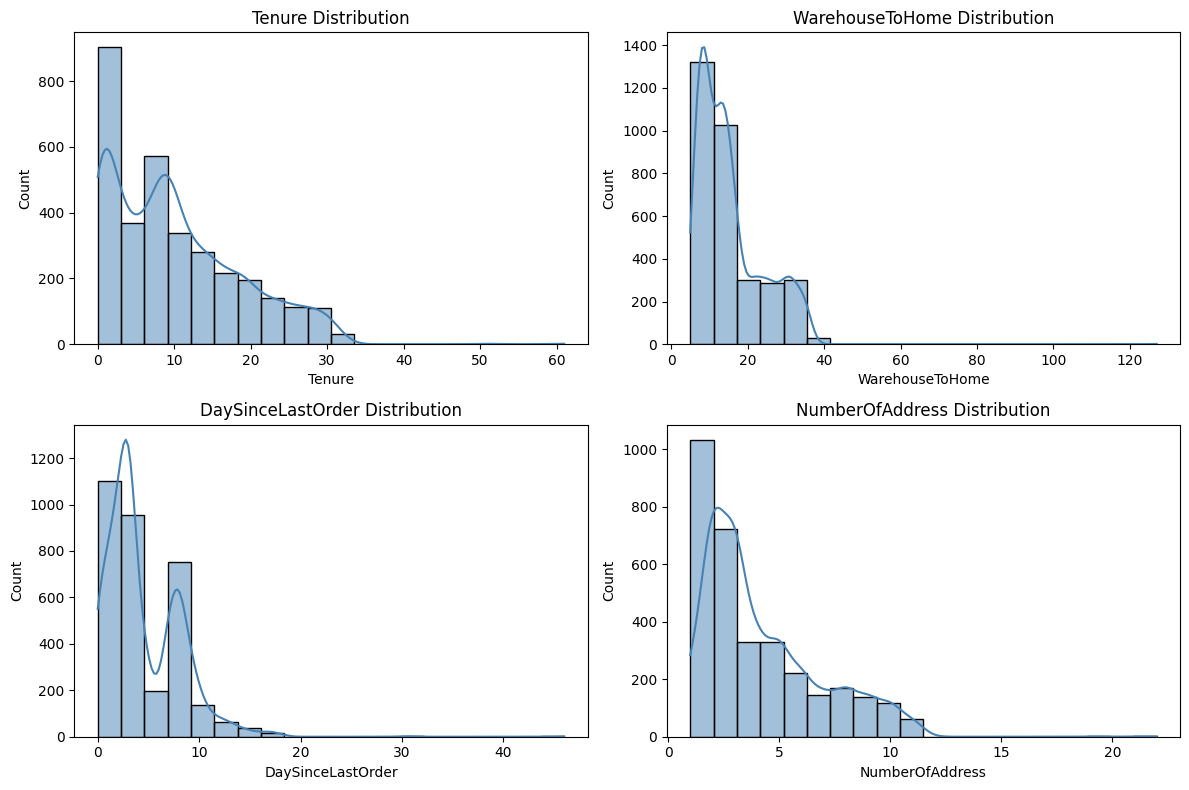

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.histplot(df['Tenure'], bins=20, kde=True, color='steelblue')
plt.title('Tenure Distribution')

plt.subplot(2, 2, 2)
sns.histplot(df['WarehouseToHome'], bins=20, kde=True, color='steelblue')
plt.title('WarehouseToHome Distribution')

plt.subplot(2, 2, 3)
sns.histplot(df['DaySinceLastOrder'], bins=20, kde=True, color='steelblue')
plt.title('DaySinceLastOrder Distribution')

plt.subplot(2, 2, 4)
sns.histplot(df['NumberOfAddress'], bins=20, kde=True, color='steelblue')
plt.title('NumberOfAddress Distribution')

plt.tight_layout()
plt.show()

**CashbackAmount** — moderate right skew, peaks at 150–175, tail to ~320. Will also log-transform.

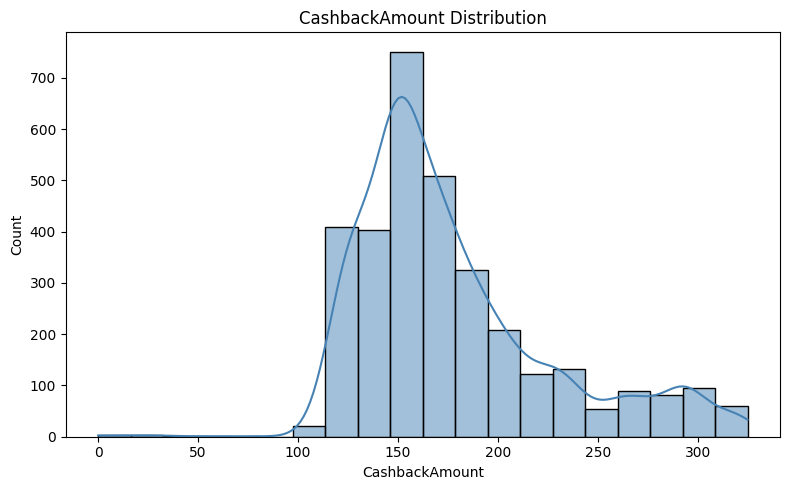

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['CashbackAmount'], bins=20, kde=True, color='steelblue')
plt.title('CashbackAmount Distribution')
plt.tight_layout()
plt.show()

**Categorical counts** — `Laptop & Accessory` is the most common order category. `Married` is the largest marital group (~1,700 customers).

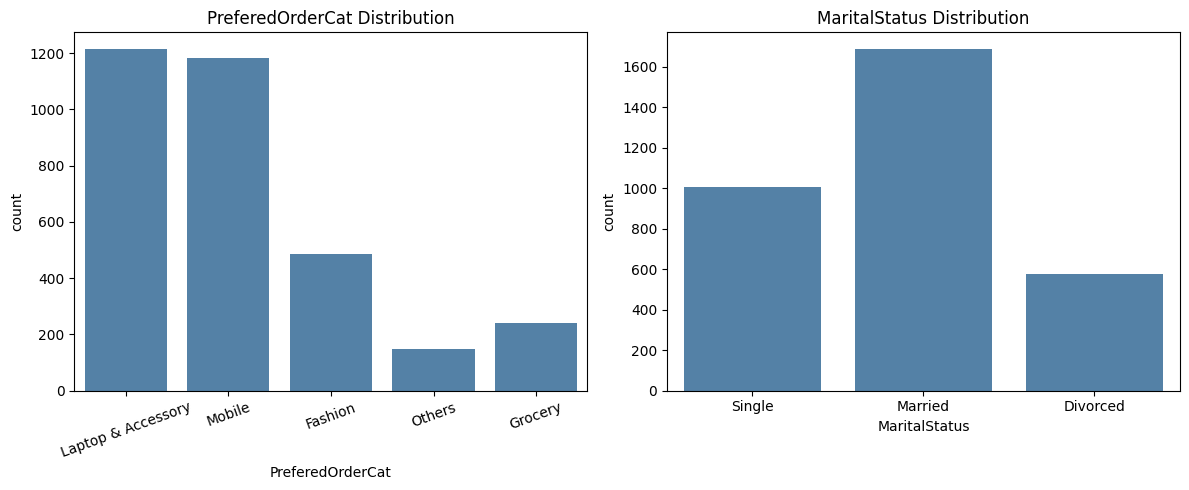

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=df['PreferedOrderCat'], color='steelblue')
plt.title('PreferedOrderCat Distribution')
plt.xticks(rotation=20)

plt.subplot(1, 2, 2)
sns.countplot(x=df['MaritalStatus'], color='steelblue')
plt.title('MaritalStatus Distribution')

plt.tight_layout()
plt.show()

**SatisfactionScore** peaks at 3 — most customers are neutral. **Complain** is a minority (~28%), but carries high churn risk as seen in bivariate analysis below.

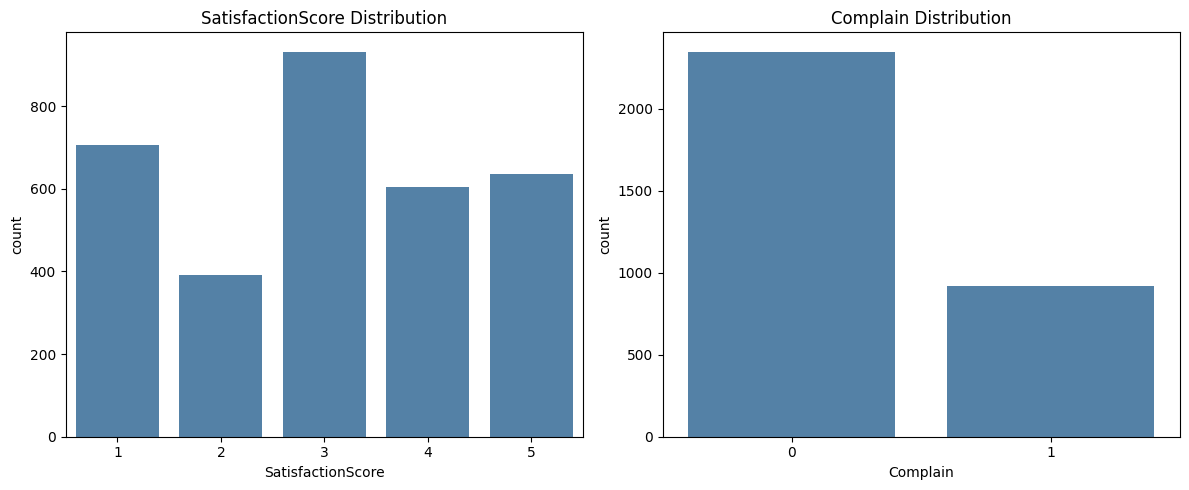

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=df['SatisfactionScore'], color='steelblue')
plt.title('SatisfactionScore Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x=df['Complain'], color='steelblue')
plt.title('Complain Distribution')

plt.tight_layout()
plt.show()

**Churn is imbalanced** — 83.7% retained, 16.3% churned. Justifies stratified splitting and SMOTE in modelling.

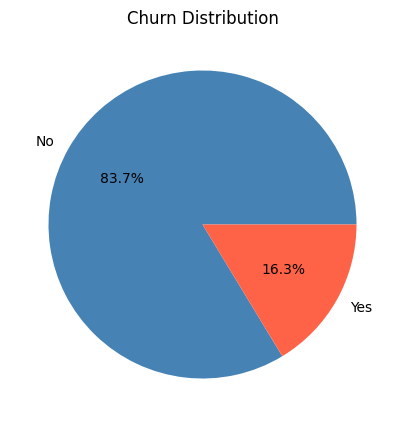

In [ ]:
plt.figure(figsize=(6, 5))
labels = ['No', 'Yes']
plt.pie(df['Churn'].value_counts(), labels=labels, autopct='%1.1f%%',
        colors=['steelblue', 'tomato'])
plt.title('Churn Distribution')
plt.show()

**Churn by category** — Mobile customers churn at 27%, 6.5× higher than Grocery (4%). Single customers churn at 26%, more than double Married (11%).

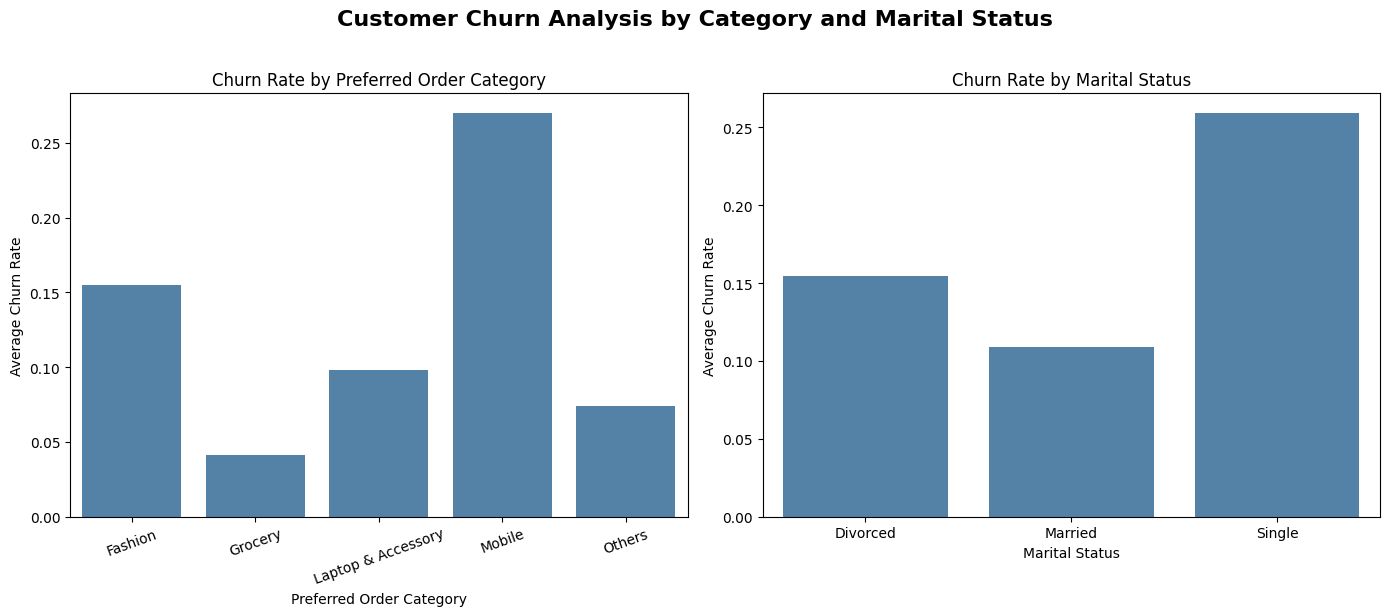

In [ ]:
plt.figure(figsize=(14, 6))
plt.suptitle('Customer Churn Analysis by Category and Marital Status',
             fontsize=16, fontweight='bold', y=1.02)

plt.subplot(1, 2, 1)
df2 = df.groupby('PreferedOrderCat')['Churn'].mean().reset_index()
sns.barplot(data=df2, x='PreferedOrderCat', y='Churn', color='steelblue')
plt.title('Churn Rate by Preferred Order Category')
plt.xlabel('Preferred Order Category')
plt.ylabel('Average Churn Rate')
plt.xticks(rotation=20)

plt.subplot(1, 2, 2)
df3 = df.groupby('MaritalStatus')['Churn'].mean().reset_index()
sns.barplot(data=df3, x='MaritalStatus', y='Churn', color='steelblue')
plt.title('Churn Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Average Churn Rate')

plt.tight_layout()
plt.show()

**Correlation heatmap** — `Tenure` (−0.34) is the strongest predictor: longer tenure = lower churn. `Complain` (+0.26) is the strongest positive signal. Note: categorical columns not included here — assessed separately via churn-rate bar charts above.

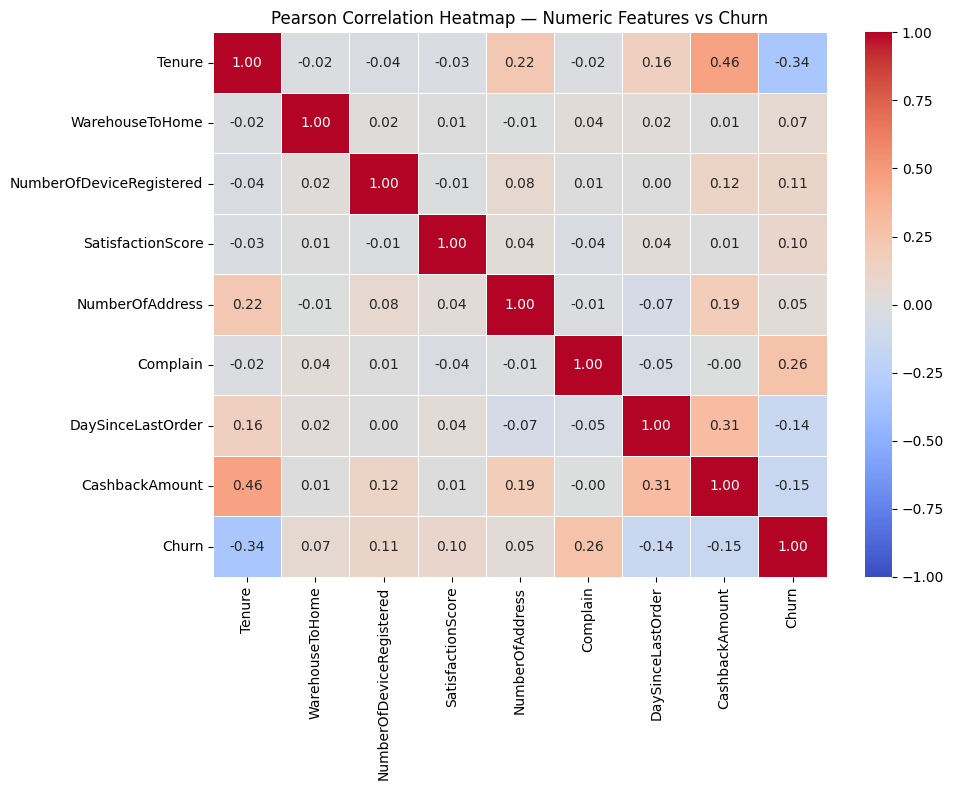

In [ ]:
cols = [
    'Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
    'SatisfactionScore', 'NumberOfAddress', 'Complain',
    'DaySinceLastOrder', 'CashbackAmount', 'Churn'
]
corr_matrix = df[cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Pearson Correlation Heatmap — Numeric Features vs Churn')
plt.tight_layout()
plt.show()

## Save Cleaned Dataset

In [ ]:
df.to_csv('data_ecommerce_customer_churn_cleaned.csv', index=False)
print('Saved.')
# files.download('data_ecommerce_customer_churn_cleaned.csv')

Saved.
